# **1. Introduction**

## 1.1 Project Overview

Image classification is a fundamental task in computer vision, enabling machines to recognize and categorize visual content. However, raw images often vary in size, lighting, and perspective, which can hinder model performance. This project focuses on classifying flower species using the Flowers Multiclass Dataset from Kaggle. We’ll build a VGG-style
CNN from scratch and fine-tune a pretrained ResNet, comparing how these approaches
affect accuracy and reliabilit

## 1.2 Dataset Overview

The Flowers Multiclass Dataset contains images of flowers categorized into five distinct classes. You can access the dataset using this [link](https://www.kaggle.com/datasets/alsaniipe/flowers-multiclass-datasets/data)

# **2. Environment Setup**

## 2.1 Import Libraries

In [126]:
import kagglehub
import zipfile
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import copy

from collections import Counter
from tqdm import tqdm
from pathlib import Path
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import LabelBinarizer

## 2.2 Configurations

In [2]:
BATCH_SIZE = 32

IMAGE_NET_MEAN = [0.485, 0.456, 0.406]
IMAGE_NET_STD = [0.229, 0.224, 0.225]

NUM_EPOCHS_VGG16 = 5
NUM_EPOCHS_RES_NET = 5

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


# **3. Dataset Loading**

## 3.1 Download Dataset

In [4]:
path = kagglehub.dataset_download(
    handle="alsaniipe/flowers-multiclass-datasets",
    path="flowers/flowers/flower_photos",
)
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/flowers-multiclass-datasets/flowers/flowers/flower_photos


In [5]:
dataset_dir = Path(path)
print("Dataset contents:", os.listdir(dataset_dir))

Dataset contents: ['validation', 'test', 'train']


In [6]:
train_dir = dataset_dir / "train"
val_dir = dataset_dir / "validation"
test_dir = dataset_dir / "test"

# **4. Image Preprocessing and Data Augmentation**

**1. `transforms.Resize(256)`**
- **Purpose**: Resizes the image's shorter edge to **256 pixels** while maintaining aspect ratio.
- **Why?**  
  - Preserves original proportions better than forcing a square resize
  - Retains more fine details for subsequent cropping
  - Standard practice for high-quality preprocessing (used in ResNet/VGG papers)
- **Technical Note**: Uses bilinear interpolation by default. For a 300x400 image → 192x256 (maintaining 3:4 ratio).

---

**2. `transforms.RandomCrop(224)` (Training Only)**
- **Purpose**: Extracts a random **224×224 patch** from the resized image.
- **Why? (Data Augmentation)**  
  - Forces model to recognize objects from different compositions
  - Simulates real-world partial visibility of objects
  - Effectively multiplies training data variability
- **Example**: From a 256x256 image, generates ~100+ possible unique 224x224 crops.

---

**3. `transforms.CenterCrop(224)` (Validation/Test)**
- **Purpose**: Extracts the center **224×224 region**.
- **Why?**  
  - Ensures consistent evaluation on the most "important" image region
  - Matches how most pretrained models were validated
  - Removes randomness during model testing

---

**4. `transforms.RandomHorizontalFlip(p=0.5)`**
- **Purpose**: Flips images horizontally with **50% probability**.
- **Why?**  
  - Effectively doubles training data for symmetric objects
  - Makes model invariant to left/right orientation
  - Computational "free" augmentation (no image distortion)
- **Note**: Critical for natural images but may hurt tasks where direction matters (e.g., text recognition).

---

**5. `transforms.RandomRotation(20)`**
- **Purpose**: Rotates image randomly between **-20° and +20°**.
- **Why?**  
  - Accounts for natural camera angle variations
  - Teaches model rotation-invariant features
  - Especially useful for flower datasets where orientation varies
- **Edge Handling**: By default, rotated empty areas fill with black (configurable).

---

**6. `transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)`**
- **Purpose**: Randomly adjusts:
  - Brightness (±20%)
  - Contrast (±20%)
  - Saturation (±20%)
- **Why?**  
  - Simulates different lighting conditions
  - Makes model robust to color variations
  - Helps with white balance differences in photos

---

**7. `transforms.ToTensor()`**
- **Purpose**: Converts PIL Image → PyTorch Tensor.
- **Critical Operations**:
  - Changes data layout to `(C, H, W)`
  - Scales values from [0,255] → [0.0,1.0]
  - Automatically handles grayscale → 1-channel or RGB → 3-channel
- **Watch Out**: Always place this before normalization!

---

**8. `transforms.Normalize(mean=[...], std=[...])`**
- **Purpose**: Standardizes values using ImageNet statistics.
- **Per-Channel Operations**:
  ```
  Red: (x - 0.485)/0.229
  Green: (x - 0.456)/0.224
  Blue: (x - 0.406)/0.225
  ```
- **Why These Values?**  
  - ImageNet dataset averages (over 1M images)
  - Most pretrained models expect this input range
  - Normalized models train faster and generalize better

---

1. **Order Matters**: Geometric → Color → Tensor → Normalize
2. **Augmentation Only in Training**:
   - Validation uses `CenterCrop` instead of `RandomCrop`
   - Validation skips flips/rotation/color jitter
3. **Why 256→224?**:
   - Gives the model "context" around the final crop
   - Preserves details better than direct 224 resize

---

In [7]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_transform)

In [10]:
print("\n=== Dataset Class Information ===")
num_classes = len(train_dataset.classes)
print(f"Total classes: {num_classes}")
print(f"Class names: {train_dataset.classes}\n")


=== Dataset Class Information ===
Total classes: 5
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']



In [11]:
def get_class_distribution(dataset):
    class_counts = Counter()
    for _, label in dataset:
        class_counts[label] += 1
    return class_counts

train_counts = get_class_distribution(train_dataset)
val_counts = get_class_distribution(val_dataset)
test_counts = get_class_distribution(test_dataset)

In [12]:
total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())

print("\n=== Dataset Summary ===")
print(f"Total training images: {total_train}")
print(f"Total validation images: {total_val}")
print(f"Total test images: {total_test}")
print(f"Total images across all splits: {total_train + total_val + total_test}")


=== Dataset Summary ===
Total training images: 3540
Total validation images: 80
Total test images: 50
Total images across all splits: 3670


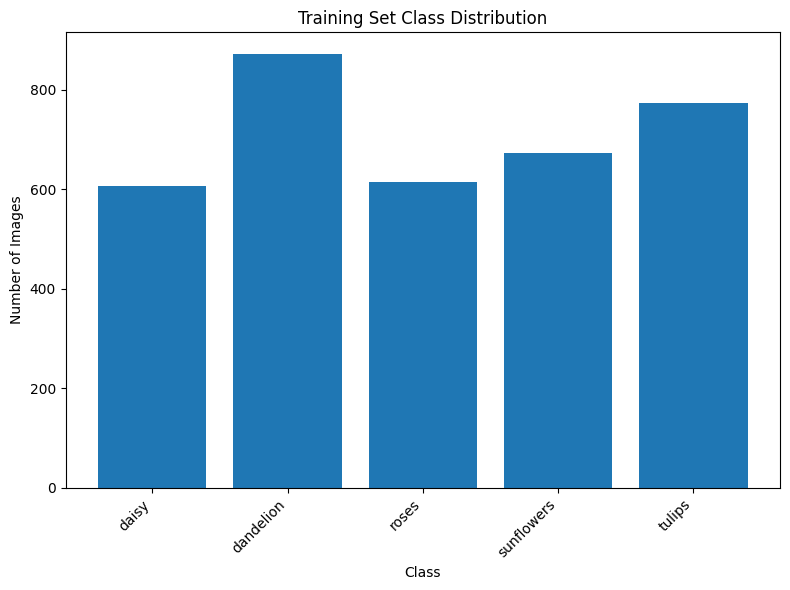

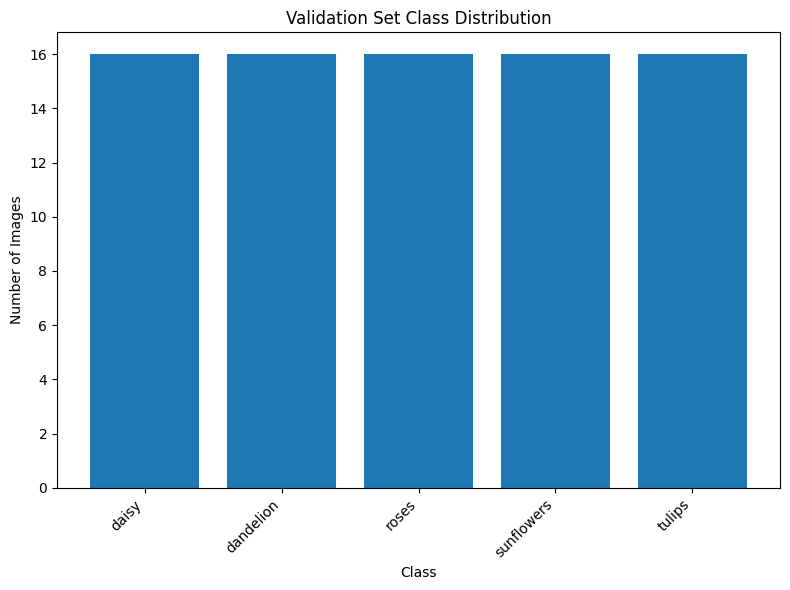

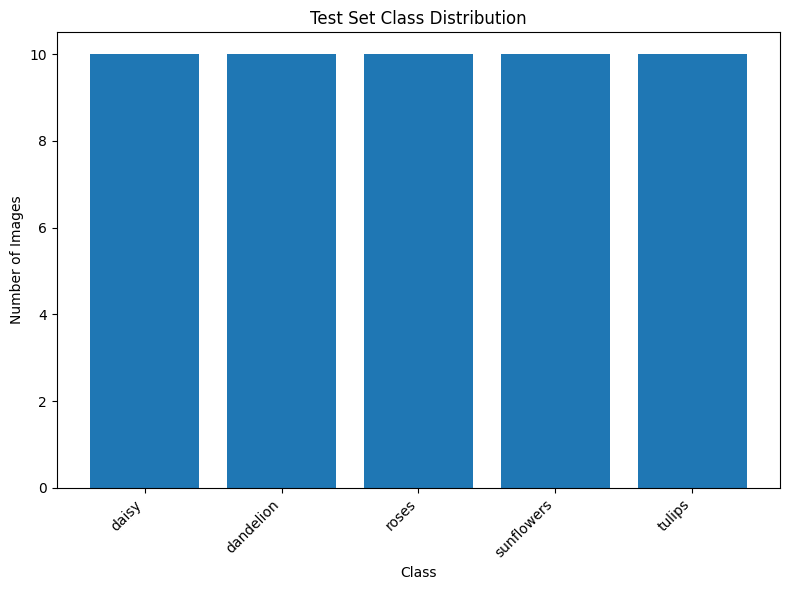

In [13]:
def plot_class_distribution(counts, title, class_names):
    plt.figure(figsize=(8, 6))
    plt.bar([class_names[i] for i in counts.keys()], counts.values())
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

class_names = train_dataset.classes
plot_class_distribution(train_counts, "Training Set Class Distribution", class_names)
plot_class_distribution(val_counts, "Validation Set Class Distribution", class_names)
plot_class_distribution(test_counts, "Test Set Class Distribution", class_names)

# **5. Encoding**

## 5.1. Label Encoding

PyTorch default - already implemented in ImageFolder, ImageFolder automatically uses label encoding (class indices)

In [14]:
print("Label encoding examples:")
for i in range(3):
    img, label = train_dataset[i]
    print(f"Sample {i}: Class index = {label}, Class name = {train_dataset.classes[label]}")

Label encoding examples:
Sample 0: Class index = 0, Class name = daisy
Sample 1: Class index = 0, Class name = daisy
Sample 2: Class index = 0, Class name = daisy


## 5.2 One Hot Encoding

In [15]:
class OneHotDataset(Dataset):
    def __init__(self, original_dataset):
        self.original_dataset = original_dataset
        self.num_classes = len(original_dataset.classes)

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        image, label = self.original_dataset[idx]
        one_hot_label = F.one_hot(torch.tensor(label), num_classes=self.num_classes).float()
        return image, one_hot_label

In [16]:
train_dataset_onehot = OneHotDataset(train_dataset)
val_dataset_onehot = OneHotDataset(val_dataset)
test_dataset_onehot = OneHotDataset(test_dataset)

In [17]:
print("\nOne-hot encoding examples:")
for i in range(3):
    img, one_hot = train_dataset_onehot[i]
    class_idx = torch.argmax(one_hot).item()
    print(f"Sample {i}: One-hot = {one_hot}, Class name = {train_dataset.classes[class_idx]}")


One-hot encoding examples:
Sample 0: One-hot = tensor([1., 0., 0., 0., 0.]), Class name = daisy
Sample 1: One-hot = tensor([1., 0., 0., 0., 0.]), Class name = daisy
Sample 2: One-hot = tensor([1., 0., 0., 0., 0.]), Class name = daisy


# **6. PyTorch Data Loader**

In [18]:
label_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
label_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
label_test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
onehot_train_loader = DataLoader(train_dataset_onehot, batch_size=BATCH_SIZE, shuffle=True)
onehot_val_loader = DataLoader(val_dataset_onehot, batch_size=BATCH_SIZE, shuffle=False)
onehot_test_loader = DataLoader(test_dataset_onehot, batch_size=BATCH_SIZE, shuffle=False)

# **7. Model Training and Evaluation**

In [ ]:
def train_model(model, data_loader, criterion, is_one_hot_encoding,
                num_epochs, learning_rate=0.001):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer,
                                  mode='min',
                                  factor=0.5,
                                  patience=2)
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(data_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            if is_one_hot_encoding:
                loss = criterion(outputs, labels.float())
            else:
                loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(data_loader)
        scheduler.step(epoch_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | LR: {current_lr:.5f}")

    return model

In [ ]:
def evaluate_model(model, dataloader, class_names, is_one_hot_encoding):
    model.eval()
    all_preds = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if is_one_hot_encoding:
                probabilities = torch.sigmoid(outputs)
                preds = torch.argmax(probabilities, dim=1)
                labels = torch.argmax(labels, dim=1)
            else:
                probabilities = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"MODEL EVALUATION METRICS")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"{'='*60}")

    report = classification_report(all_labels, all_preds,
                                 target_names=class_names,
                                 digits=4, zero_division=0)
    print(f"\nDETAILED CLASSIFICATION REPORT:")
    print(f"{report}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold')

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=axes[0, 0])
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')
    axes[0, 0].set_title('Confusion Matrix')
    axes[0, 0].tick_params(axis='x', rotation=45)

    per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    x = np.arange(len(class_names))
    width = 0.25

    axes[0, 1].bar(x - width, per_class_precision, width, label='Precision', alpha=0.8)
    axes[0, 1].bar(x, per_class_recall, width, label='Recall', alpha=0.8)
    axes[0, 1].bar(x + width, per_class_f1, width, label='F1-Score', alpha=0.8)

    axes[0, 1].set_xlabel('Classes')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].set_title('Per-Class Metrics')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    n_classes = len(class_names)

    label_binarizer = LabelBinarizer()
    y_true_binary = label_binarizer.fit_transform(all_labels)
    if n_classes == 2:
        y_true_binary = np.hstack((1 - y_true_binary, y_true_binary))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], all_probabilities[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        axes[1, 0].plot(fpr[i], tpr[i], color=color, lw=2,
                       label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curves')
    axes[1, 0].legend(loc="lower right", fontsize='small')
    axes[1, 0].grid(True, alpha=0.3)

    auc_scores = [roc_auc[i] for i in range(n_classes)]
    bars = axes[1, 1].bar(class_names, auc_scores, color=colors, alpha=0.7)
    axes[1, 1].set_xlabel('Classes')
    axes[1, 1].set_ylabel('AUC Score')
    axes[1, 1].set_title('AUC Scores by Class')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)

    for bar, score in zip(bars, auc_scores):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\nAUC SCORES SUMMARY:")
    print(f"{'='*40}")
    for i, class_name in enumerate(class_names):
        print(f"{class_name:15s}: {roc_auc[i]:.4f}")

    mean_auc = np.mean(auc_scores)
    print(f"{'Mean AUC':15s}: {mean_auc:.4f}")
    print(f"{'='*40}")

# **8. Building a VGG CNN from Scratch**

A Convolutional Neural Network (CNN) architecture is a deep learning model designed for processing structured grid-like data, such as images. It consists of multiple layers, including convolutional, pooling, and fully connected layers. CNNs are highly effective for tasks like image classification, object detection, and image segmentation due to their hierarchical feature extraction capabilities.

The VGG-16 model is a convolutional neural network (CNN) architecture that was proposed by the Visual Geometry Group (VGG) at the University of Oxford. It is characterized by its depth, consisting of 16 layers, including 13 convolutional layers and 3 fully connected layers. VGG-16 is renowned for its simplicity and effectiveness, as well as its ability to achieve strong performance on various computer vision tasks, including image classification and object recognition. The model's architecture features a stack of convolutional layers followed by max-pooling layers, with progressively increasing depth. This design enables the model to learn intricate hierarchical representations of visual features, leading to robust and accurate predictions. Despite its simplicity compared to more recent architectures, VGG-16 remains a popular choice for many deep learning applications due to its versatility and excellent performance.

## 8.1 Model Definition

In [20]:
class VGG16(nn.Module):
    def __init__(self, num_classes):
        super(VGG16, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

## 8.2 Model Training

### 8.2.1 Label Encoding Data

In [134]:
vgg_model_label_encodig = train_model(model=VGG16(num_classes),
                                      data_loader=label_train_loader,
                                      criterion=nn.CrossEntropyLoss(),
                                      is_one_hot_encoding=False,
                                      num_epochs=NUM_EPOCHS_VGG16)

Epoch 1/5: 100%|██████████| 111/111 [01:15<00:00,  1.48it/s]



Epoch [1/5] | Loss: 1.6119 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [01:13<00:00,  1.51it/s]



Epoch [2/5] | Loss: 1.6024 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [01:13<00:00,  1.50it/s]



Epoch [3/5] | Loss: 1.6008 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [01:13<00:00,  1.50it/s]



Epoch [4/5] | Loss: 1.6010 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [01:14<00:00,  1.50it/s]


Epoch [5/5] | Loss: 1.6009 | LR: 0.00100


### 8.2.2 One Hot Encoding Data

In [136]:
vgg_model_one_hot_encodig = train_model(model=VGG16(num_classes),
                                        data_loader=onehot_train_loader,
                                        criterion=nn.BCEWithLogitsLoss(),
                                        is_one_hot_encoding=True,
                                        num_epochs=NUM_EPOCHS_VGG16)

Epoch 1/5: 100%|██████████| 111/111 [01:15<00:00,  1.47it/s]



Epoch [1/5] | Loss: 0.5186 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [01:14<00:00,  1.49it/s]



Epoch [2/5] | Loss: 0.5008 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [01:14<00:00,  1.48it/s]



Epoch [3/5] | Loss: 0.5008 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [01:14<00:00,  1.49it/s]



Epoch [4/5] | Loss: 0.4997 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [01:14<00:00,  1.50it/s]


Epoch [5/5] | Loss: 0.4992 | LR: 0.00100


## 8.3 Model Evaluation

### 8.3.1 Label Encoding Data


MODEL EVALUATION METRICS
Accuracy:  0.2000 (20.00%)
Precision: 0.0400
Recall:    0.2000
F1-Score:  0.0667

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     0.0000    0.0000    0.0000        16
   dandelion     0.2000    1.0000    0.3333        16
       roses     0.0000    0.0000    0.0000        16
  sunflowers     0.0000    0.0000    0.0000        16
      tulips     0.0000    0.0000    0.0000        16

    accuracy                         0.2000        80
   macro avg     0.0400    0.2000    0.0667        80
weighted avg     0.0400    0.2000    0.0667        80



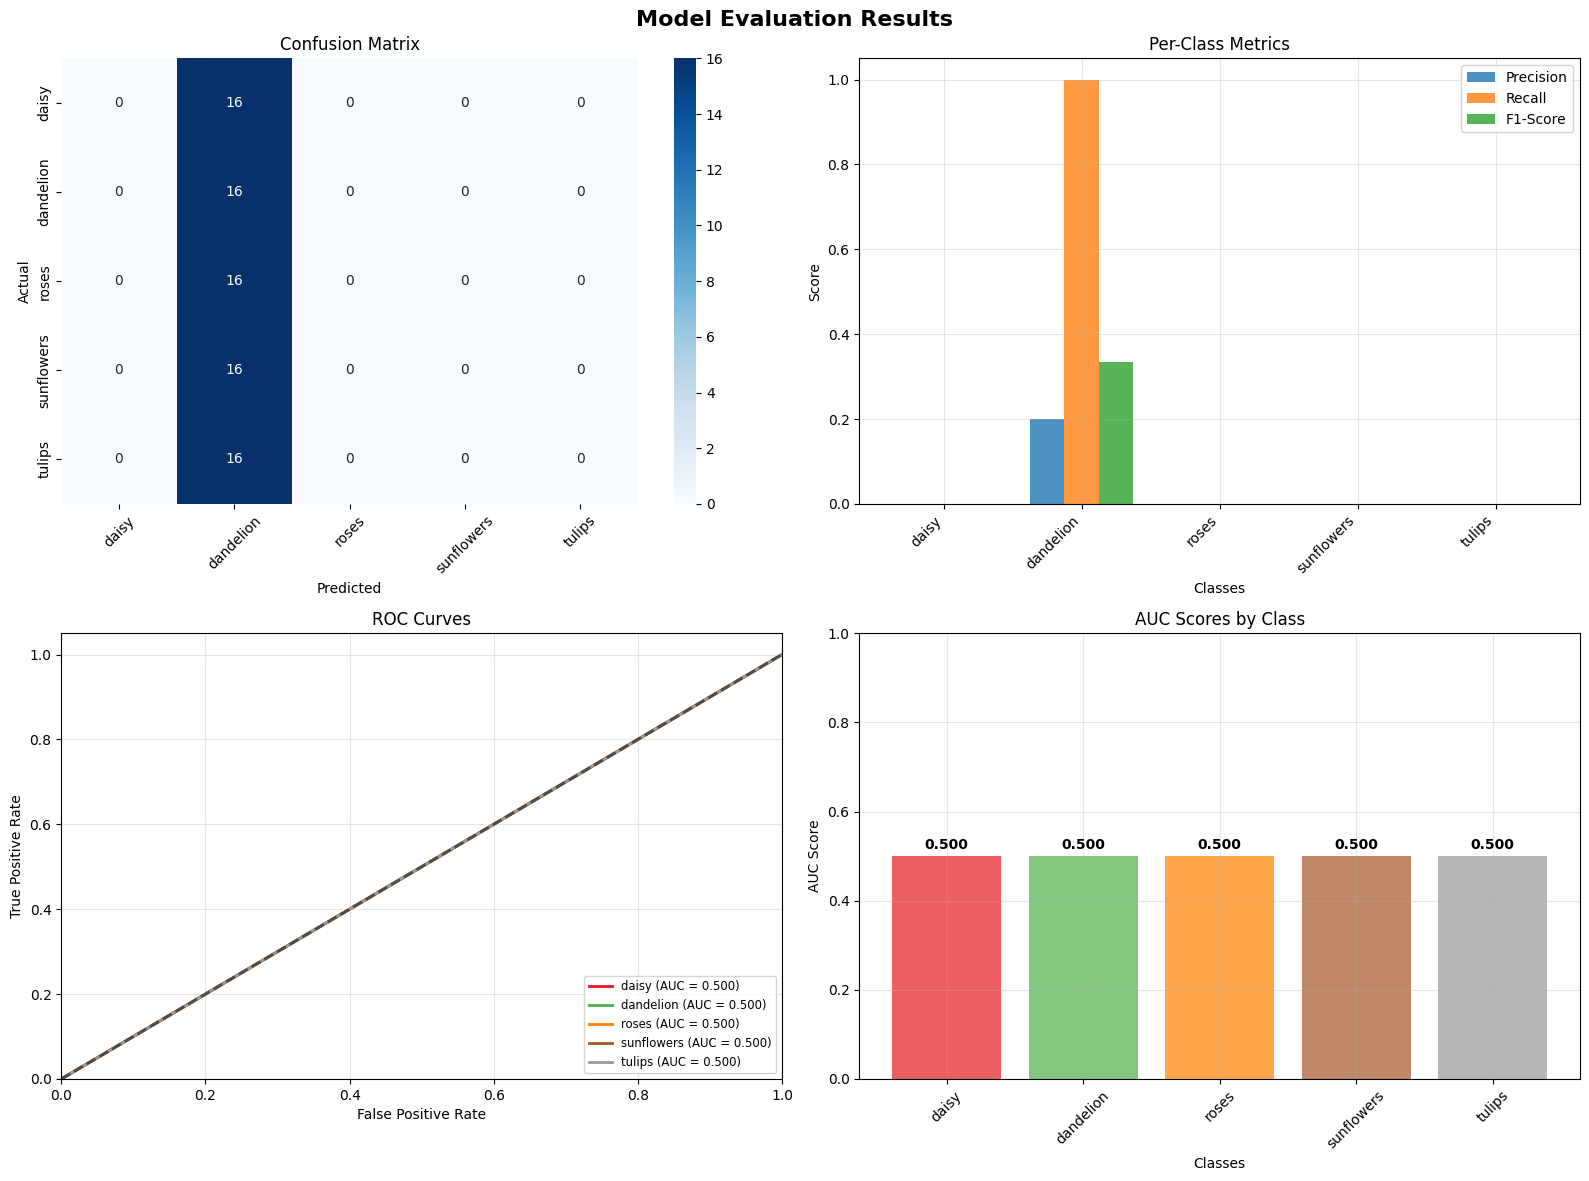


AUC SCORES SUMMARY:
daisy          : 0.5000
dandelion      : 0.5000
roses          : 0.5000
sunflowers     : 0.5000
tulips         : 0.5000
Mean AUC       : 0.5000


In [135]:
evaluate_model(model=vgg_model_label_encodig,
               dataloader=label_val_loader,
               class_names=class_names,
               is_one_hot_encoding=False)

### 8.3.2 One Hot Encoding Data


MODEL EVALUATION METRICS
Accuracy:  0.2000 (20.00%)
Precision: 0.0400
Recall:    0.2000
F1-Score:  0.0667

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     0.0000    0.0000    0.0000        16
   dandelion     0.0000    0.0000    0.0000        16
       roses     0.0000    0.0000    0.0000        16
  sunflowers     0.0000    0.0000    0.0000        16
      tulips     0.2000    1.0000    0.3333        16

    accuracy                         0.2000        80
   macro avg     0.0400    0.2000    0.0667        80
weighted avg     0.0400    0.2000    0.0667        80



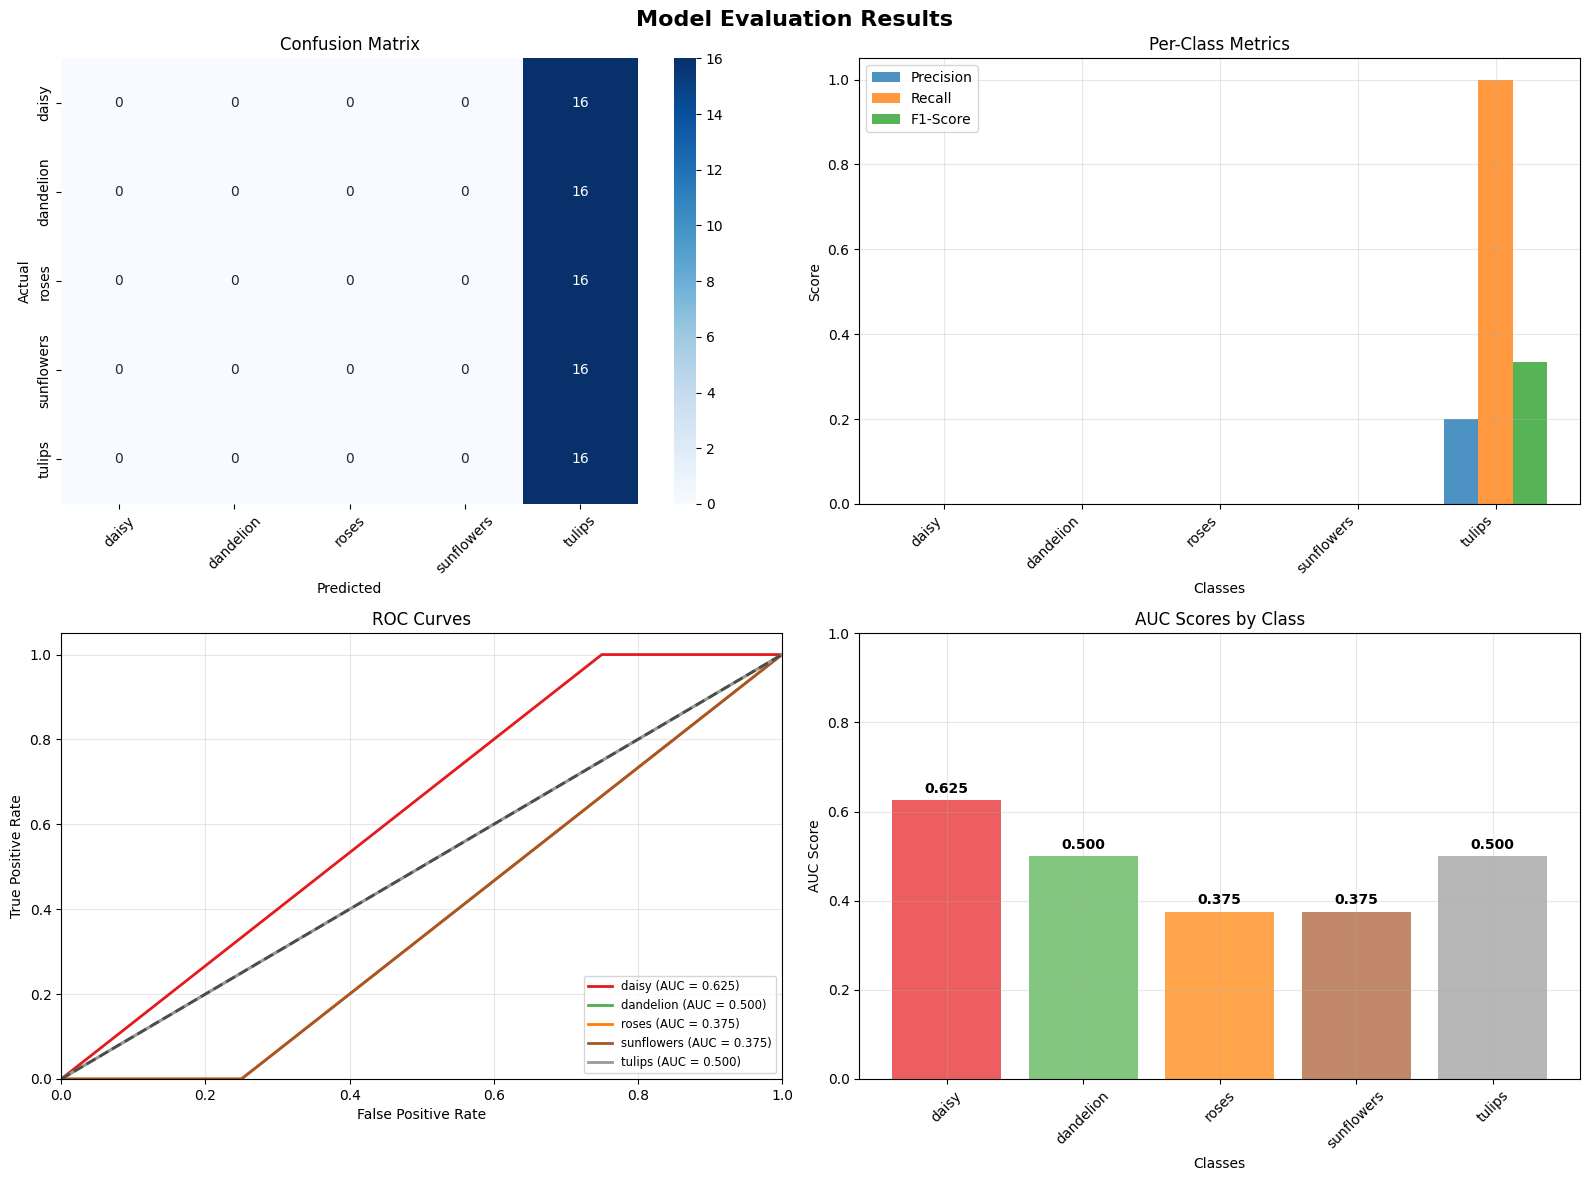


AUC SCORES SUMMARY:
daisy          : 0.6250
dandelion      : 0.5000
roses          : 0.3750
sunflowers     : 0.3750
tulips         : 0.5000
Mean AUC       : 0.4750


In [137]:
evaluate_model(model=vgg_model_one_hot_encodig,
               dataloader=onehot_val_loader,
               class_names=class_names,
               is_one_hot_encoding=True)



 Label Encoding

* Assigns each class a **single integer**, e.g.:

  ```
  cat -> 0
  dog -> 1
  bird -> 2
  ```
* This introduces an **implicit ordinal relationship**:

  * The model might think `dog (1)` is closer to `cat (0)` than to `bird (2)`, which is **not true** for class labels.



 One-Hot Encoding

* Represents each class as a **binary vector**, e.g.:

  ```
  cat  -> [1, 0, 0]
  dog  -> [0, 1, 0]
  bird -> [0, 0, 1]
  ```
* No implied order — each class is **equidistant** from the others.
* This aligns better with what a classification model like **VGG16** is learning: **distinct class categories**.


The last layer of VGG16 gives a **vector of class scores**, typically passed through `softmax`:

  ```python
  [0.01, 0.03, ..., 0.90, ..., 0.02]
  ```
* It expects targets in the **same format** — which one-hot encoding provides.



 Misleading Numerical Relationships

* With label encoding, the model might infer that class `2` is somehow “twice” as much as class `1`.
* This makes sense in regression but not in classification.
* One-hot encoding removes this ambiguity.


Imagine you have 3 classes:

* car (0)
* airplane (1)
* elephant (2)

Using label encoding suggests:

```
elephant - airplane = 1
airplane - car = 1
=> elephant - car = 2
```

But there’s no real-world metric where this makes sense.

With one-hot:

```
car       = [1, 0, 0]
airplane  = [0, 1, 0]
elephant  = [0, 0, 1]
```

Each class is equally distinct.



# **9. Fine-Tuning a Pretrained ResNet**

ResNet (Residual Neural Network) is a deep convolutional neural network (CNN) architecture introduced by Microsoft Research in 2015 ("Deep Residual Learning for Image Recognition" by Kaiming He et al.). It revolutionized deep learning by enabling the training of extremely deep networks (100+ layers) without suffering from the vanishing gradient problem.

## 9.1 Load Pretrained ResNet50

In [138]:
resnet_model = models.resnet50(weights='IMAGENET1K_V2')

In [139]:
classifier = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
).to(device)

## 9.2 Training Model and Evaluation

### 9.2.1 Freeze Base, Train Head

In [140]:
model_freeze_base = copy.deepcopy(resnet_model)

for param in model_freeze_base.parameters():
    param.requires_grad = False

model_freeze_base.fc = classifier

#### 9.2.1.1 One Hot Encoding

In [141]:
one_hot_model_freeze_base = copy.deepcopy(model_freeze_base)

In [142]:
one_hot_model_freeze_base = train_model(
    model=one_hot_model_freeze_base,
    data_loader=onehot_train_loader,
    criterion=nn.BCEWithLogitsLoss(),
    is_one_hot_encoding=True,
    num_epochs=NUM_EPOCHS_RES_NET
)

Epoch 1/5: 100%|██████████| 111/111 [00:34<00:00,  3.25it/s]



Epoch [1/5] | Loss: 0.2641 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [00:33<00:00,  3.27it/s]



Epoch [2/5] | Loss: 0.1363 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [00:34<00:00,  3.24it/s]



Epoch [3/5] | Loss: 0.1117 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [00:34<00:00,  3.23it/s]



Epoch [4/5] | Loss: 0.0929 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [00:34<00:00,  3.24it/s]


Epoch [5/5] | Loss: 0.0871 | LR: 0.00100



MODEL EVALUATION METRICS
Accuracy:  0.8875 (88.75%)
Precision: 0.8954
Recall:    0.8875
F1-Score:  0.8864

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     1.0000    0.8750    0.9333        16
   dandelion     0.9412    1.0000    0.9697        16
       roses     0.9231    0.7500    0.8276        16
  sunflowers     0.8000    1.0000    0.8889        16
      tulips     0.8125    0.8125    0.8125        16

    accuracy                         0.8875        80
   macro avg     0.8954    0.8875    0.8864        80
weighted avg     0.8954    0.8875    0.8864        80



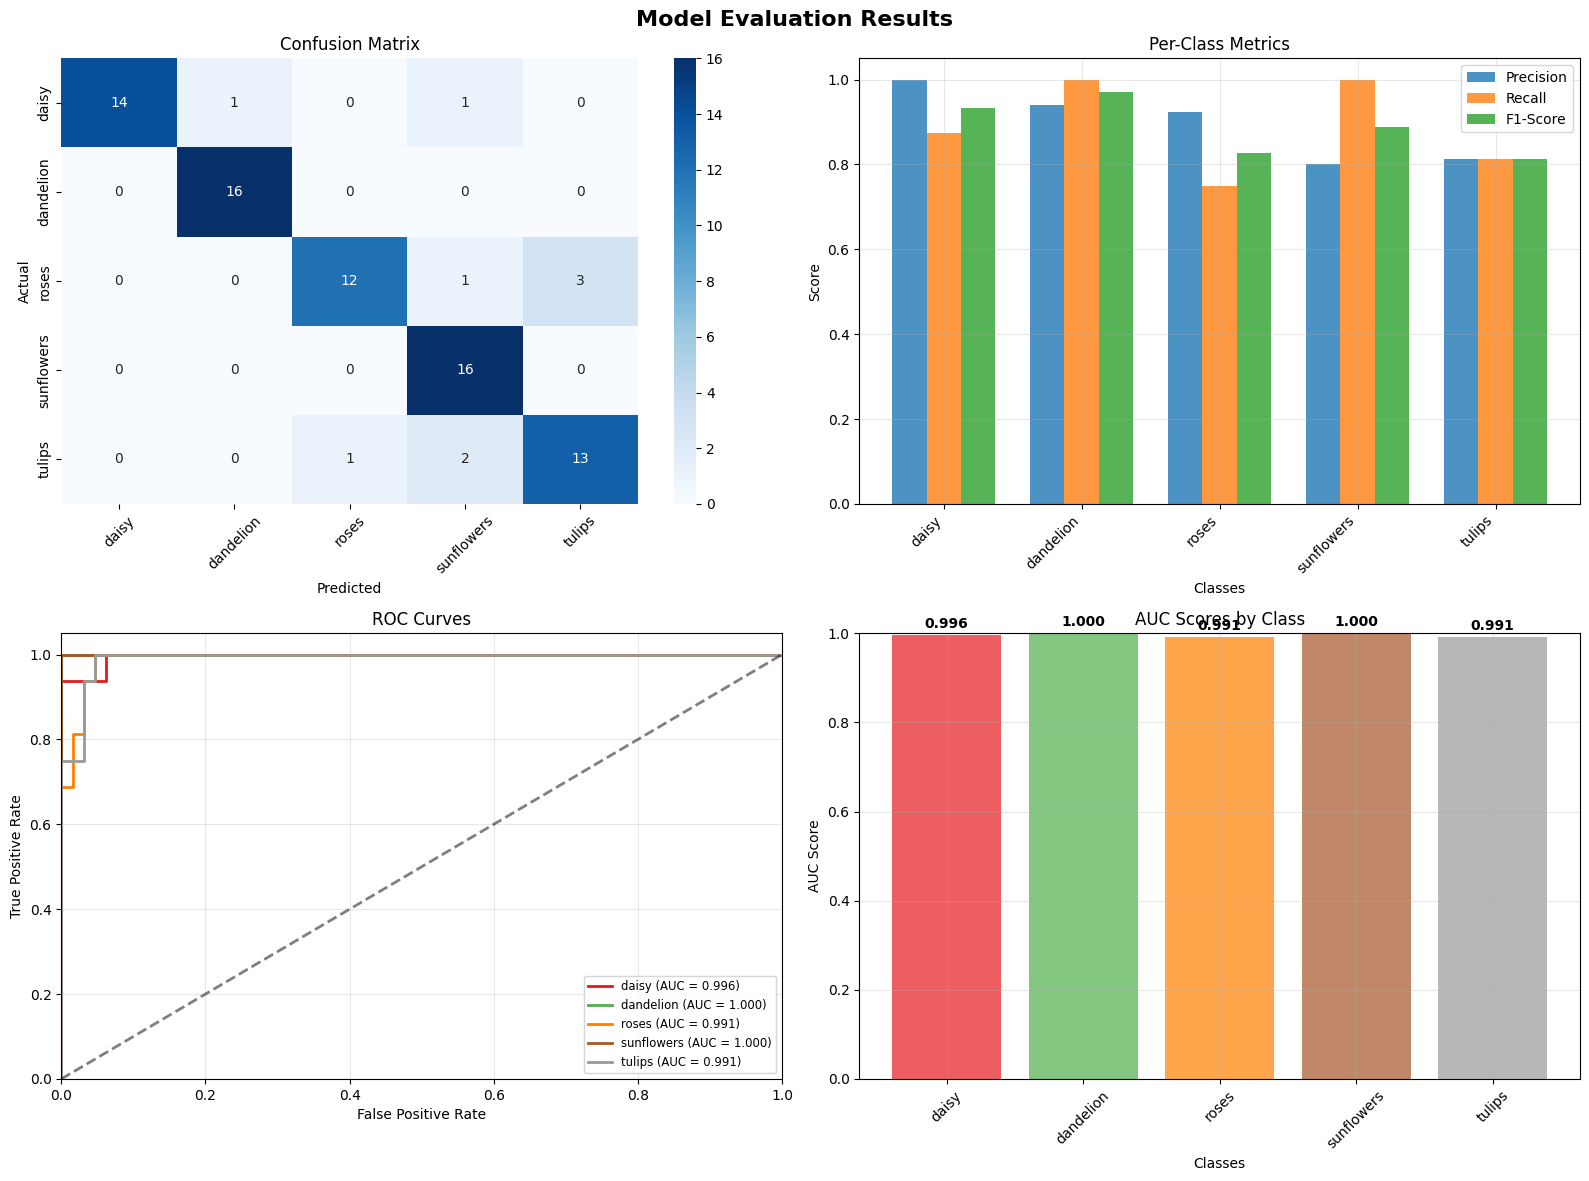


AUC SCORES SUMMARY:
daisy          : 0.9961
dandelion      : 1.0000
roses          : 0.9912
sunflowers     : 1.0000
tulips         : 0.9912
Mean AUC       : 0.9957


In [143]:
evaluate_model(
    model=one_hot_model_freeze_base,
    dataloader=onehot_val_loader,
    class_names=class_names,
    is_one_hot_encoding=True
)

#### 9.2.1.2 Label Encoding

In [144]:
label_model_freeze_base = copy.deepcopy(model_freeze_base)

In [145]:
label_model_freeze_base = train_model(
    model=label_model_freeze_base,
    data_loader=label_train_loader,
    criterion=nn.CrossEntropyLoss(),
    is_one_hot_encoding=False,
    num_epochs=NUM_EPOCHS_RES_NET
)

Epoch 1/5: 100%|██████████| 111/111 [00:34<00:00,  3.25it/s]



Epoch [1/5] | Loss: 0.6158 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [00:34<00:00,  3.25it/s]



Epoch [2/5] | Loss: 0.3250 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [00:34<00:00,  3.26it/s]



Epoch [3/5] | Loss: 0.2643 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [00:34<00:00,  3.26it/s]



Epoch [4/5] | Loss: 0.2368 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [00:33<00:00,  3.30it/s]


Epoch [5/5] | Loss: 0.1873 | LR: 0.00100



MODEL EVALUATION METRICS
Accuracy:  0.9125 (91.25%)
Precision: 0.9134
Recall:    0.9125
F1-Score:  0.9112

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     0.9333    0.8750    0.9032        16
   dandelion     0.9412    1.0000    0.9697        16
       roses     0.9286    0.8125    0.8667        16
  sunflowers     0.8889    1.0000    0.9412        16
      tulips     0.8750    0.8750    0.8750        16

    accuracy                         0.9125        80
   macro avg     0.9134    0.9125    0.9112        80
weighted avg     0.9134    0.9125    0.9112        80



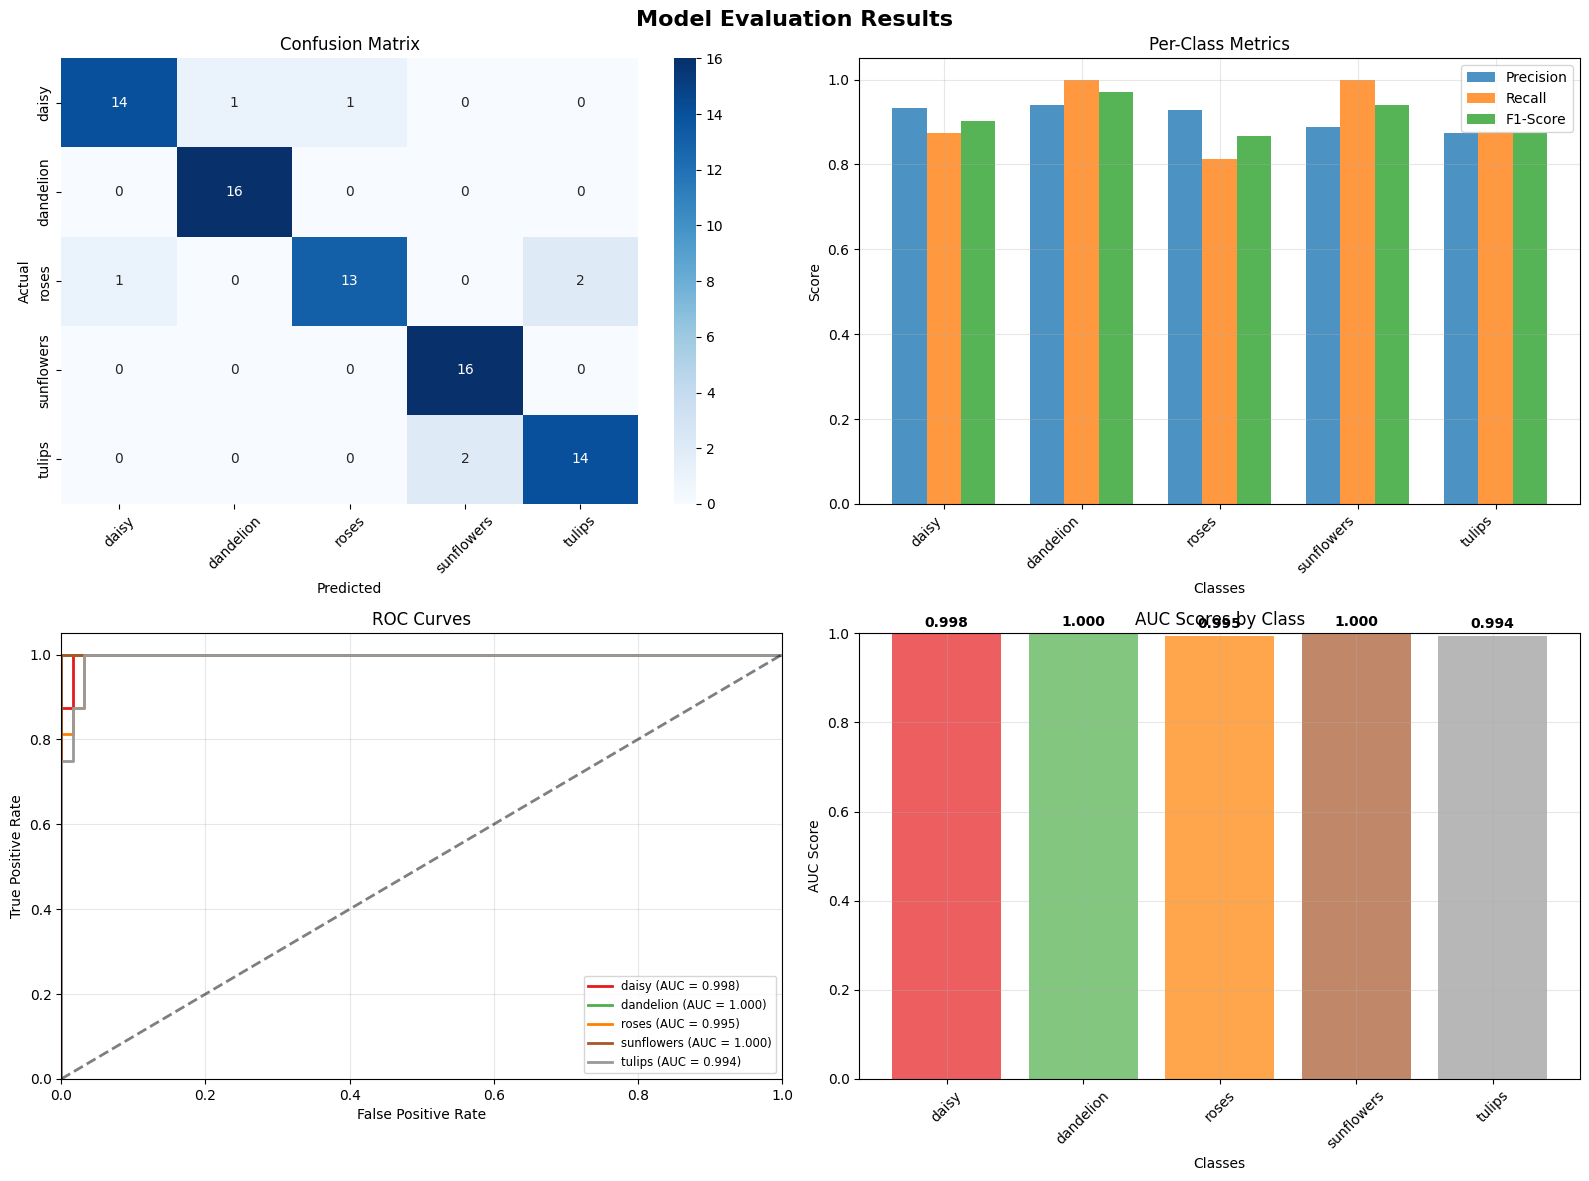


AUC SCORES SUMMARY:
daisy          : 0.9980
dandelion      : 1.0000
roses          : 0.9951
sunflowers     : 1.0000
tulips         : 0.9941
Mean AUC       : 0.9975


In [146]:
evaluate_model(
    model=label_model_freeze_base,
    dataloader=label_val_loader,
    class_names=class_names,
    is_one_hot_encoding=False
)

### 9.2.2 Unfreeze Last Conv Layer

In [147]:
unfreeze_last_conv_model = copy.deepcopy(resnet_model)

In [148]:
for name, param in unfreeze_last_conv_model.named_parameters():
    if not 'layer4' in name:
        param.requires_grad = False

unfreeze_last_conv_model.fc = classifier

#### 9.2.2.1 One Hot Encoding

In [149]:
one_hot_unfreeze_last_conv_model = copy.deepcopy(unfreeze_last_conv_model)

In [150]:
one_hot_unfreeze_last_conv_model = train_model(
    model=one_hot_unfreeze_last_conv_model,
    data_loader=onehot_train_loader,
    criterion=nn.BCEWithLogitsLoss(),
    is_one_hot_encoding=True,
    num_epochs=NUM_EPOCHS_RES_NET
)

Epoch 1/5: 100%|██████████| 111/111 [00:38<00:00,  2.88it/s]



Epoch [1/5] | Loss: 0.1644 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [00:38<00:00,  2.91it/s]



Epoch [2/5] | Loss: 0.0766 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [00:38<00:00,  2.89it/s]



Epoch [3/5] | Loss: 0.0514 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [00:38<00:00,  2.87it/s]



Epoch [4/5] | Loss: 0.0457 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [00:38<00:00,  2.86it/s]


Epoch [5/5] | Loss: 0.0380 | LR: 0.00100



MODEL EVALUATION METRICS
Accuracy:  0.9375 (93.75%)
Precision: 0.9422
Recall:    0.9375
F1-Score:  0.9373

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     1.0000    0.8750    0.9333        16
   dandelion     0.8889    1.0000    0.9412        16
       roses     0.9333    0.8750    0.9032        16
  sunflowers     1.0000    0.9375    0.9677        16
      tulips     0.8889    1.0000    0.9412        16

    accuracy                         0.9375        80
   macro avg     0.9422    0.9375    0.9373        80
weighted avg     0.9422    0.9375    0.9373        80



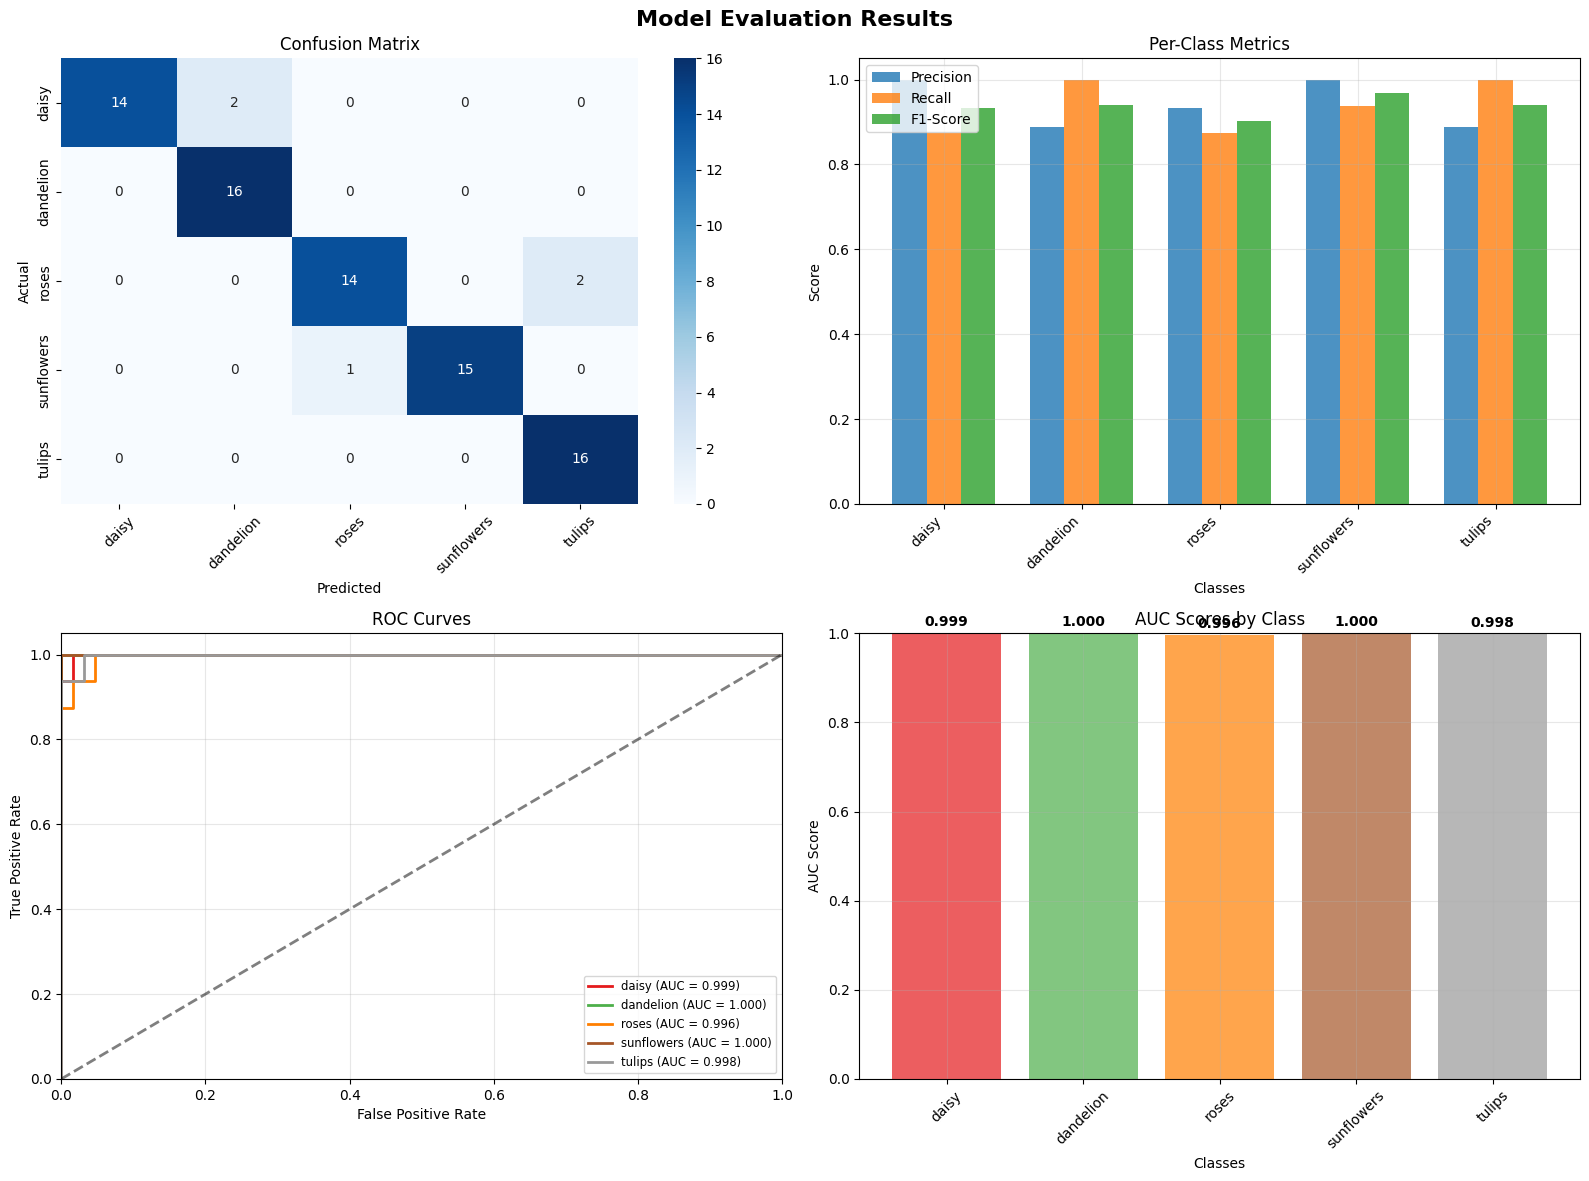


AUC SCORES SUMMARY:
daisy          : 0.9990
dandelion      : 1.0000
roses          : 0.9961
sunflowers     : 1.0000
tulips         : 0.9980
Mean AUC       : 0.9986


In [151]:
evaluate_model(
    model=one_hot_unfreeze_last_conv_model,
    dataloader=onehot_val_loader,
    class_names=class_names,
    is_one_hot_encoding=True
)

#### 9.2.2.2 Label Encoding

In [152]:
label_unfreeze_last_conv_model = copy.deepcopy(unfreeze_last_conv_model)

In [153]:
label_unfreeze_last_conv_model = train_model(
    model=label_unfreeze_last_conv_model,
    data_loader=label_train_loader,
    criterion=nn.CrossEntropyLoss(),
    is_one_hot_encoding=False,
    num_epochs=NUM_EPOCHS_RES_NET
)

Epoch 1/5: 100%|██████████| 111/111 [00:38<00:00,  2.91it/s]



Epoch [1/5] | Loss: 0.4416 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [00:38<00:00,  2.91it/s]



Epoch [2/5] | Loss: 0.1973 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [00:38<00:00,  2.88it/s]



Epoch [3/5] | Loss: 0.1450 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [00:38<00:00,  2.92it/s]



Epoch [4/5] | Loss: 0.1202 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [00:38<00:00,  2.91it/s]


Epoch [5/5] | Loss: 0.0797 | LR: 0.00100



MODEL EVALUATION METRICS
Accuracy:  0.9750 (97.50%)
Precision: 0.9757
Recall:    0.9750
F1-Score:  0.9750

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     1.0000    0.9375    0.9677        16
   dandelion     1.0000    1.0000    1.0000        16
       roses     0.9375    0.9375    0.9375        16
  sunflowers     1.0000    1.0000    1.0000        16
      tulips     0.9412    1.0000    0.9697        16

    accuracy                         0.9750        80
   macro avg     0.9757    0.9750    0.9750        80
weighted avg     0.9757    0.9750    0.9750        80



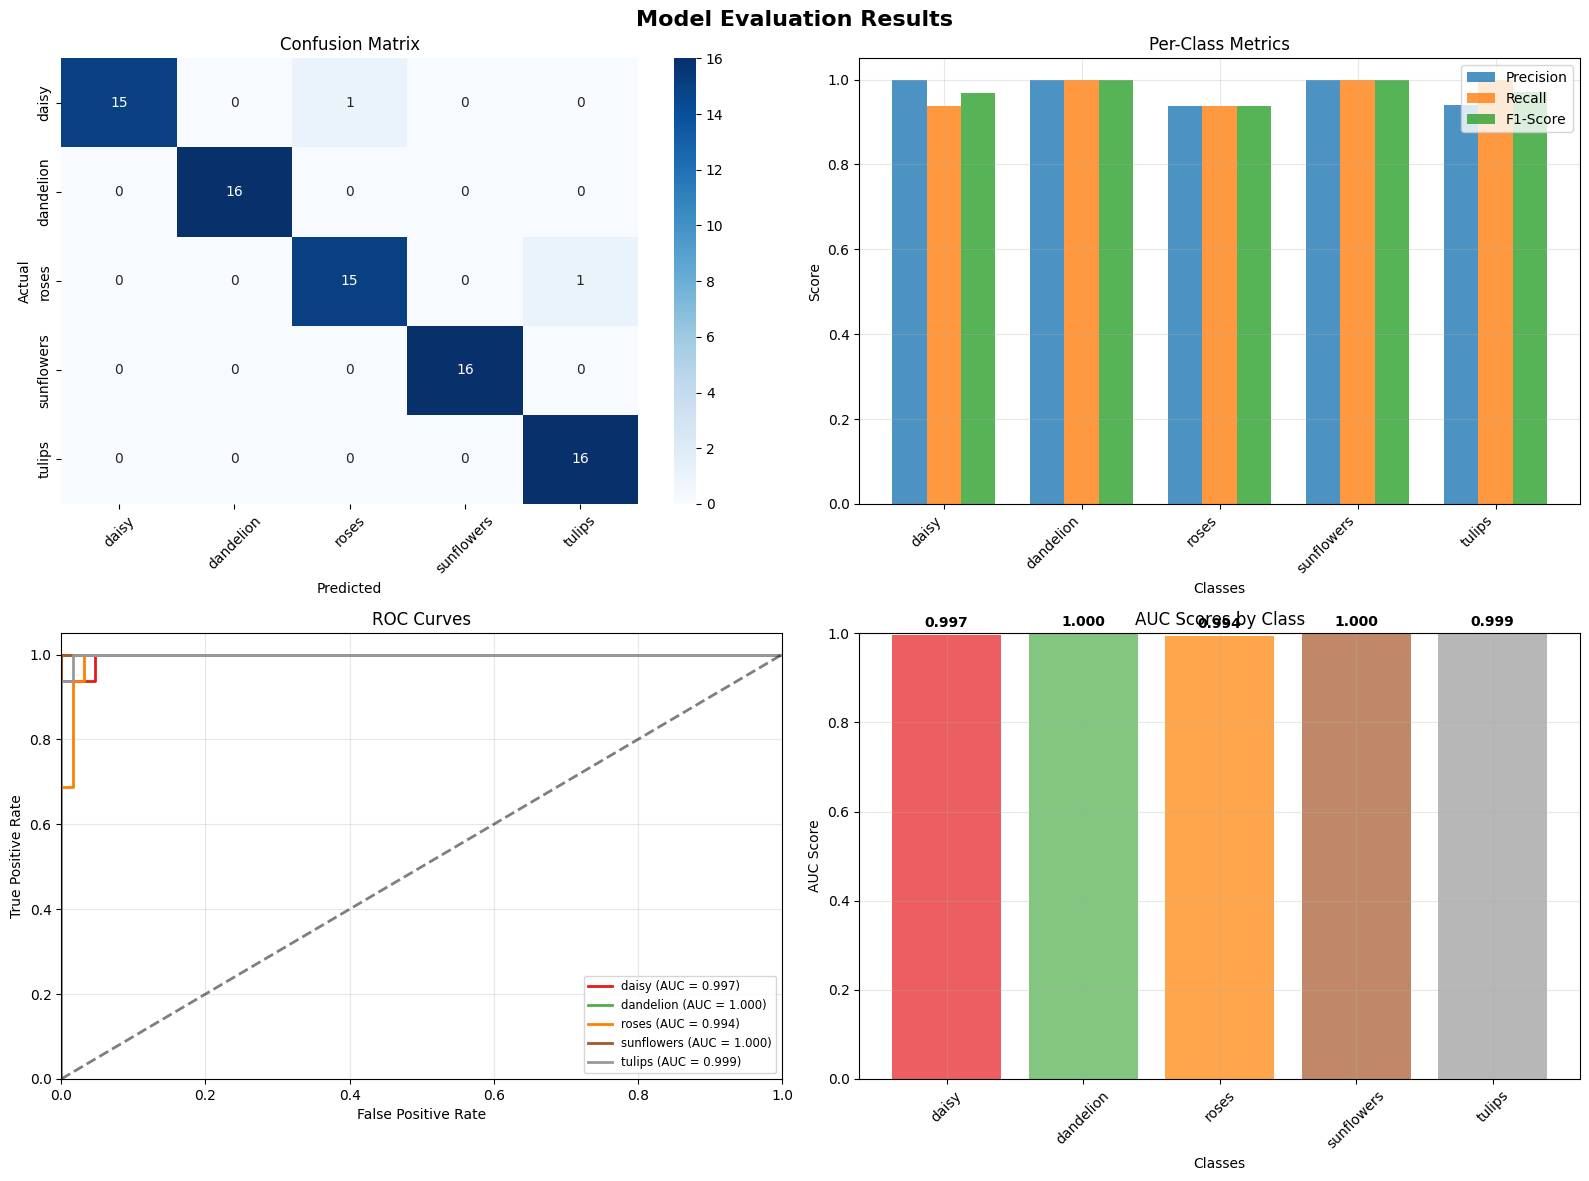


AUC SCORES SUMMARY:
daisy          : 0.9971
dandelion      : 1.0000
roses          : 0.9941
sunflowers     : 1.0000
tulips         : 0.9990
Mean AUC       : 0.9980


In [154]:
evaluate_model(
    model=label_unfreeze_last_conv_model,
    dataloader=label_val_loader,
    class_names=class_names,
    is_one_hot_encoding=False
)

### 9.2.3 Unfreeze All

In [155]:
unfreeze_all_model = copy.deepcopy(resnet_model)

In [156]:
unfreeze_all_model.fc = classifier

#### 9.2.3.1 One Hot Encoding

In [157]:
one_hot_unfreeze_all_model = copy.deepcopy(unfreeze_all_model)

In [158]:
one_hot_unfreeze_all_model = train_model(
    model=one_hot_unfreeze_all_model,
    data_loader=onehot_train_loader,
    criterion=nn.BCEWithLogitsLoss(),
    is_one_hot_encoding=True,
    num_epochs=NUM_EPOCHS_RES_NET
)

Epoch 1/5: 100%|██████████| 111/111 [00:57<00:00,  1.94it/s]



Epoch [1/5] | Loss: 0.2331 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [00:57<00:00,  1.94it/s]



Epoch [2/5] | Loss: 0.1587 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [00:57<00:00,  1.93it/s]



Epoch [3/5] | Loss: 0.1382 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [00:57<00:00,  1.93it/s]



Epoch [4/5] | Loss: 0.1208 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [00:56<00:00,  1.95it/s]


Epoch [5/5] | Loss: 0.1092 | LR: 0.00100



MODEL EVALUATION METRICS
Accuracy:  0.9000 (90.00%)
Precision: 0.9025
Recall:    0.9000
F1-Score:  0.9003

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     0.9375    0.9375    0.9375        16
   dandelion     0.8750    0.8750    0.8750        16
       roses     0.8333    0.9375    0.8824        16
  sunflowers     1.0000    0.9375    0.9677        16
      tulips     0.8667    0.8125    0.8387        16

    accuracy                         0.9000        80
   macro avg     0.9025    0.9000    0.9003        80
weighted avg     0.9025    0.9000    0.9003        80



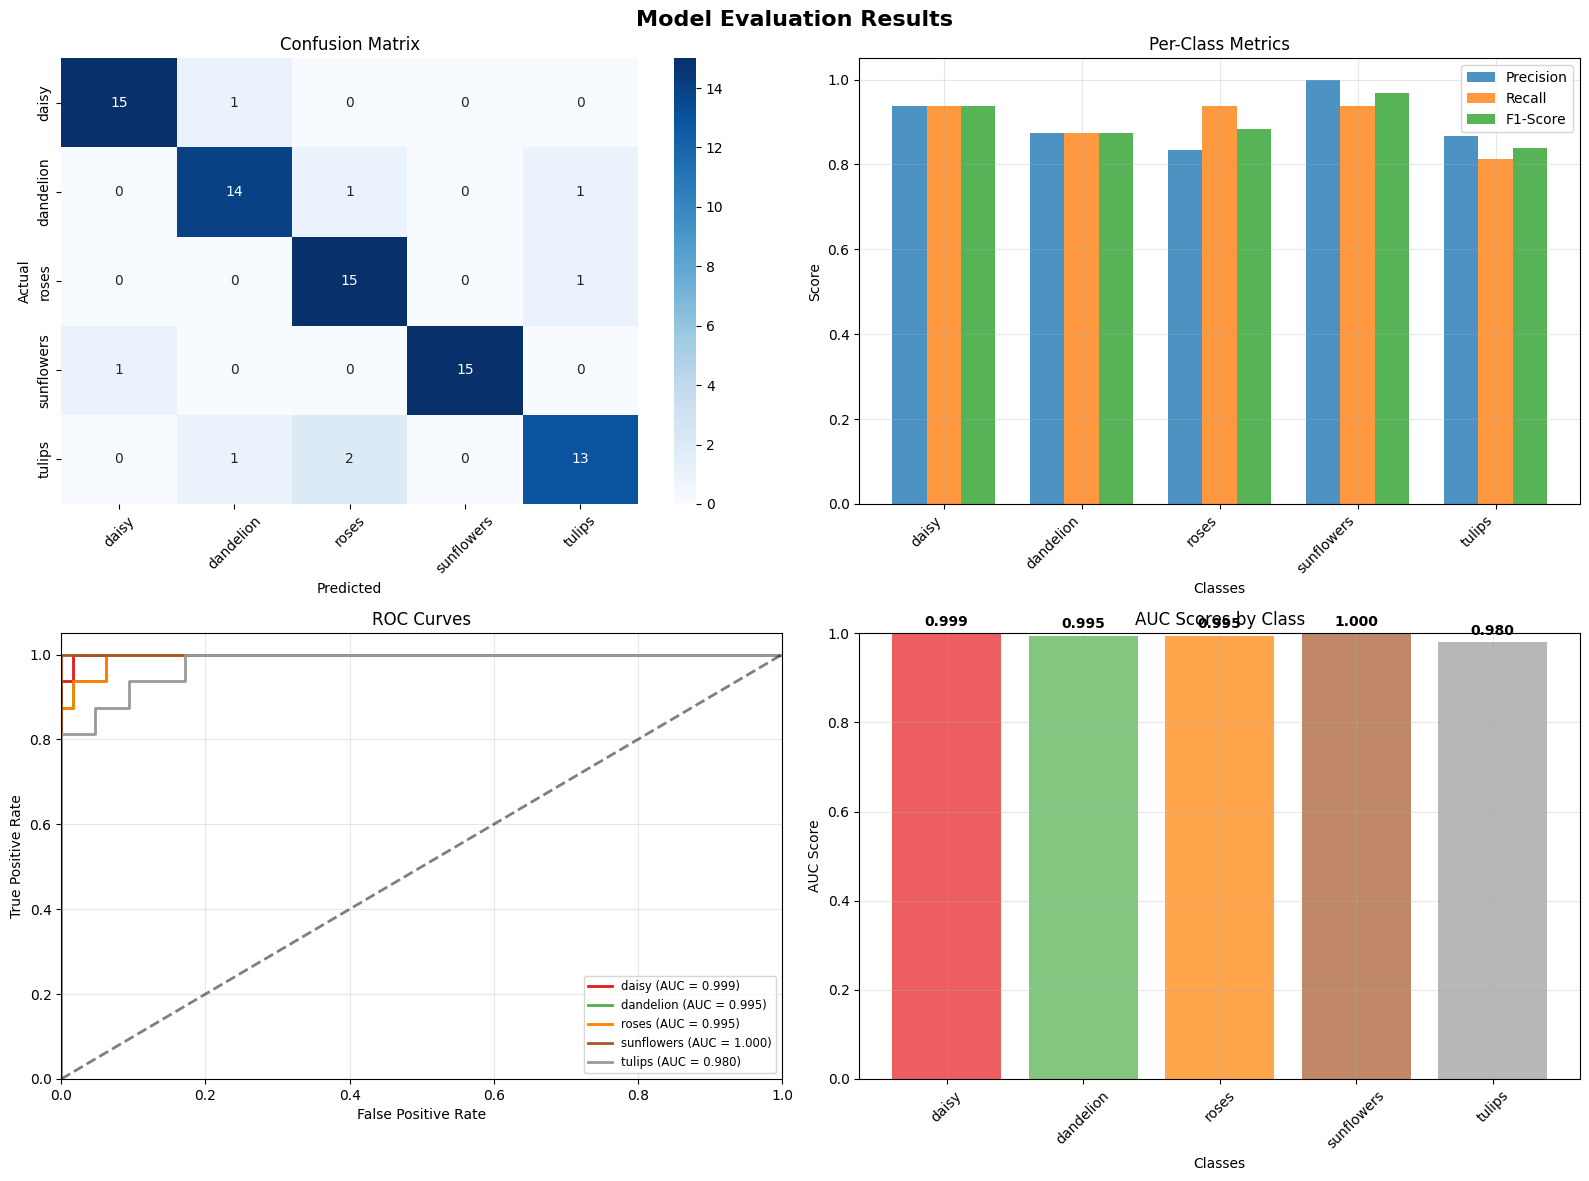


AUC SCORES SUMMARY:
daisy          : 0.9990
dandelion      : 0.9951
roses          : 0.9951
sunflowers     : 1.0000
tulips         : 0.9805
Mean AUC       : 0.9939


In [159]:
evaluate_model(
    model=one_hot_unfreeze_all_model,
    dataloader=onehot_val_loader,
    class_names=class_names,
    is_one_hot_encoding=True
)

#### 9.2.3.2 Label Encoding

In [114]:
label_unfreeze_all_model = copy.deepcopy(unfreeze_all_model)

In [115]:
label_unfreeze_all_model = train_model(
    model=label_unfreeze_all_model,
    data_loader=label_train_loader,
    criterion=nn.CrossEntropyLoss(),
    is_one_hot_encoding=False,
    num_epochs=NUM_EPOCHS_RES_NET
)

Epoch 1/5: 100%|██████████| 111/111 [00:58<00:00,  1.88it/s]



Epoch [1/5] | Loss: 0.6965 | LR: 0.00100


Epoch 2/5: 100%|██████████| 111/111 [00:58<00:00,  1.90it/s]



Epoch [2/5] | Loss: 0.4845 | LR: 0.00100


Epoch 3/5: 100%|██████████| 111/111 [00:58<00:00,  1.90it/s]



Epoch [3/5] | Loss: 0.4095 | LR: 0.00100


Epoch 4/5: 100%|██████████| 111/111 [00:58<00:00,  1.88it/s]



Epoch [4/5] | Loss: 0.3330 | LR: 0.00100


Epoch 5/5: 100%|██████████| 111/111 [00:58<00:00,  1.89it/s]


Epoch [5/5] | Loss: 0.2845 | LR: 0.00100



MODEL EVALUATION METRICS
Accuracy:  0.8750 (87.50%)
Precision: 0.8933
Recall:    0.8750
F1-Score:  0.8712

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       daisy     0.8889    1.0000    0.9412        16
   dandelion     1.0000    0.8750    0.9333        16
       roses     0.7778    0.8750    0.8235        16
  sunflowers     0.8000    1.0000    0.8889        16
      tulips     1.0000    0.6250    0.7692        16

    accuracy                         0.8750        80
   macro avg     0.8933    0.8750    0.8712        80
weighted avg     0.8933    0.8750    0.8712        80



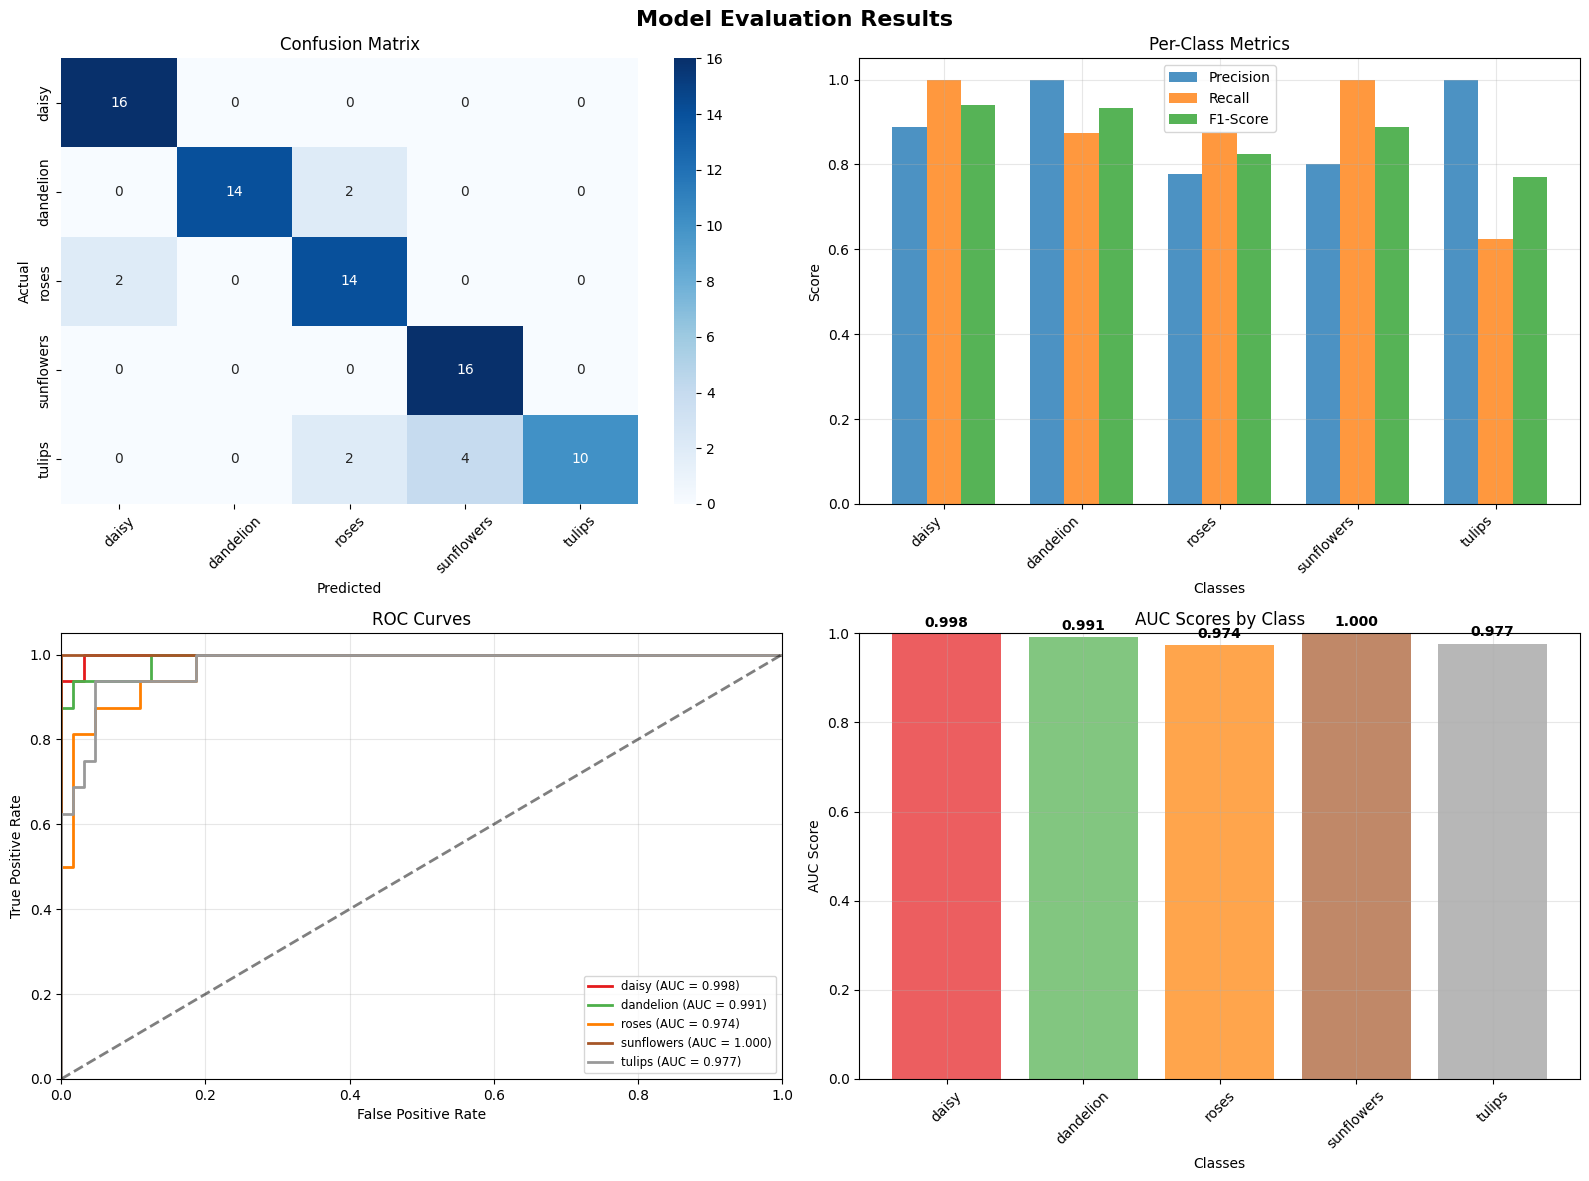


AUC SCORES SUMMARY:
daisy          : 0.9980
dandelion      : 0.9912
roses          : 0.9736
sunflowers     : 1.0000
tulips         : 0.9766
Mean AUC       : 0.9879


{'accuracy': 0.875,
 'precision': 0.8933333333333333,
 'recall': 0.875,
 'f1_score': 0.8712317747611866,
 'per_class_precision': array([0.88888889, 1.        , 0.77777778, 0.8       , 1.        ]),
 'per_class_recall': array([1.   , 0.875, 0.875, 1.   , 0.625]),
 'per_class_f1': array([0.94117647, 0.93333333, 0.82352941, 0.88888889, 0.76923077]),
 'auc_scores': [np.float64(0.998046875),
  np.float64(0.9912109375),
  np.float64(0.9736328125),
  np.float64(1.0),
  np.float64(0.9765625)],
 'mean_auc': np.float64(0.987890625),
 'confusion_matrix': array([[16,  0,  0,  0,  0],
        [ 0, 14,  2,  0,  0],
        [ 2,  0, 14,  0,  0],
        [ 0,  0,  0, 16,  0],
        [ 0,  0,  2,  4, 10]]),
 'classification_report': '              precision    recall  f1-score   support\n\n       daisy     0.8889    1.0000    0.9412        16\n   dandelion     1.0000    0.8750    0.9333        16\n       roses     0.7778    0.8750    0.8235        16\n  sunflowers     0.8000    1.0000    0.8889       

In [121]:
evaluate_model(
    model=label_unfreeze_all_model,
    dataloader=label_val_loader,
    class_names=class_names,
    is_one_hot_encoding=False
)